In [1]:
import os
import re
from typing import Optional, Tuple, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def parse_imu_log(
    path: str,
    entity_filter: Optional[str] = None,
    use_header_time: bool = True,
    default_rate_hz: float = 100.0,
) -> pd.DataFrame:
    """
    Parse a gz echo-style IMU log into a DataFrame with columns:
      t, entity_name, qx, qy, qz, qw, wx, wy, wz, ax, ay, az

    If header stamps (sec/nsec) exist and use_header_time=True, t is seconds from start.
    Otherwise, t is synthesized from sample index and default_rate_hz.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    # Patterns
    p_header = re.compile(r"^\s*header\s*\{")
    p_entity = re.compile(r'^\s*entity_name:\s*"([^"]+)"')
    p_stamp_open = re.compile(r"^\s*stamp\s*\{")
    p_sec = re.compile(r"^\s*sec:\s*(-?\d+)")
    p_nsec = re.compile(r"^\s*nsec:\s*(\d+)")

    p_ori_open = re.compile(r"^\s*orientation\s*\{")
    p_ang_open = re.compile(r"^\s*angular_velocity\s*\{")
    p_acc_open = re.compile(r"^\s*linear_acceleration\s*\{")
    p_close = re.compile(r"^\s*\}")

    p_x = re.compile(r"^\s*x:\s*([-+0-9.eE]+)")
    p_y = re.compile(r"^\s*y:\s*([-+0-9.eE]+)")
    p_z = re.compile(r"^\s*z:\s*([-+0-9.eE]+)")
    p_w = re.compile(r"^\s*w:\s*([-+0-9.eE]+)")

    def fval(s: str) -> float:
        try:
            return float(s)
        except Exception:
            return np.nan

    rows: List[Dict[str, float]] = []

    # Current message state
    cur: Dict[str, float] = {}
    cur_entity: Optional[str] = None
    cur_sec: Optional[int] = None
    cur_nsec: Optional[int] = None
    in_mode: Optional[str] = None  # 'ori' | 'ang' | 'acc' | None
    in_stamp: bool = False

    def finalize():
        nonlocal cur, cur_entity, cur_sec, cur_nsec
        if not cur:
            return
        # Attach entity and timestamp if available
        cur["entity_name"] = cur_entity
        if use_header_time and (cur_sec is not None) and (cur_nsec is not None):
            cur["t_abs"] = float(cur_sec) + float(cur_nsec) * 1e-9
        else:
            cur["t_abs"] = np.nan
        rows.append(cur)
        cur = {}

    with open(path, "r") as f:
        for line in f:
            # New message begins
            if p_header.search(line):
                finalize()
                cur = {}
                cur_entity = None
                cur_sec = None
                cur_nsec = None
                in_mode = None
                in_stamp = False
                continue

            # entity_name
            m = p_entity.search(line)
            if m:
                cur_entity = m.group(1)
                continue

            # stamp block
            if p_stamp_open.search(line):
                in_stamp = True
                continue
            if in_stamp:
                ms = p_sec.search(line)
                if ms:
                    cur_sec = int(ms.group(1))
                    continue
                mn = p_nsec.search(line)
                if mn:
                    cur_nsec = int(mn.group(1))
                    continue
                if p_close.search(line):
                    # end of stamp block
                    in_stamp = False
                    continue

            # Which block are we in?
            if p_ori_open.search(line):
                in_mode = "ori"
                continue
            if p_ang_open.search(line):
                in_mode = "ang"
                continue
            if p_acc_open.search(line):
                in_mode = "acc"
                continue

            # Close of a block
            if p_close.search(line) and in_mode is not None:
                in_mode = None
                continue

            # Numeric components
            if in_mode is not None:
                mx = p_x.search(line)
                my = p_y.search(line)
                mz = p_z.search(line)
                mw = p_w.search(line)
                if in_mode == "ori":
                    if mx: cur["qx"] = fval(mx.group(1))
                    if my: cur["qy"] = fval(my.group(1))
                    if mz: cur["qz"] = fval(mz.group(1))
                    if mw: cur["qw"] = fval(mw.group(1))
                elif in_mode == "ang":
                    if mx: cur["wx"] = fval(mx.group(1))
                    if my: cur["wy"] = fval(my.group(1))
                    if mz: cur["wz"] = fval(mz.group(1))
                elif in_mode == "acc":
                    if mx: cur["ax"] = fval(mx.group(1))
                    if my: cur["ay"] = fval(my.group(1))
                    if mz: cur["az"] = fval(mz.group(1))

    # finalize trailing
    finalize()

    if not rows:
        raise RuntimeError("No IMU messages parsed from log")

    df = pd.DataFrame(rows)

    # Filter by entity if requested
    if entity_filter:
        df = df[df["entity_name"] == entity_filter].reset_index(drop=True)

    # Time vector
    if use_header_time and np.isfinite(df["t_abs"]).any():
        # Use absolute time, normalize to start at 0
        t0 = df["t_abs"].min(skipna=True)
        df["t"] = df["t_abs"] - t0
    else:
        # Synthesize from sample index
        n = len(df)
        dt = 1.0 / float(default_rate_hz if default_rate_hz > 0 else 100.0)
        df["t"] = np.arange(n, dtype=float) * dt

    # Ensure consistent columns even if some were missing
    for col in ("qx", "qy", "qz", "qw", "wx", "wy", "wz", "ax", "ay", "az"):
        if col not in df.columns:
            df[col] = np.nan

    return df[["t", "entity_name", "qx", "qy", "qz", "qw", "wx", "wy", "wz", "ax", "ay", "az"]]


def last_window(df: pd.DataFrame, seconds: float = 30.0) -> pd.DataFrame:
    if df.empty:
        return df
    tmax = df["t"].max()
    tmin = max(0.0, tmax - float(seconds))
    return df[df["t"] >= tmin].copy().reset_index(drop=True)


def plot_imu_grid_3x4(df: pd.DataFrame, title: str = "", sharex: bool = True):
    """
    Plot 10 time series in a 3x4 grid:
      Row 1: orientation qx, qy, qz, qw
      Row 2: angular velocity wx, wy, wz (4th subplot unused)
      Row 3: linear acceleration ax, ay, az (4th subplot unused)
    """
    if df.empty:
        print("Empty DataFrame")
        return

    fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=sharex, constrained_layout=True)
    t = df["t"].values

    # Row 1: orientation
    series = [("qx", "orientation.qx"), ("qy", "orientation.qy"),
              ("qz", "orientation.qz"), ("qw", "orientation.qw")]
    for j, (col, lab) in enumerate(series):
        ax = axes[0, j]
        ax.plot(t, df[col].values, lw=1.2, color="tab:blue")
        ax.set_title(lab)
        ax.grid(True, alpha=0.3)

    # Row 2: angular velocity
    series = [("wx", "ang_vel.wx"), ("wy", "ang_vel.wy"), ("wz", "ang_vel.wz")]
    for j, (col, lab) in enumerate(series):
        ax = axes[1, j]
        ax.plot(t, df[col].values, lw=1.2, color="tab:orange")
        ax.set_title(lab)
        ax.grid(True, alpha=0.3)
    # Hide the unused 4th subplot in row 2
    axes[1, 3].axis("off")

    # Row 3: linear acceleration
    series = [("ax", "lin_acc.ax"), ("ay", "lin_acc.ay"), ("az", "lin_acc.az")]
    for j, (col, lab) in enumerate(series):
        ax = axes[2, j]
        ax.plot(t, df[col].values, lw=1.2, color="tab:green")
        ax.set_title(lab)
        ax.grid(True, alpha=0.3)
    # Hide the unused 4th subplot in row 3
    axes[2, 3].axis("off")

    # Labels
    for i in range(3):
        axes[i, 0].set_ylabel("value")
    for j in range(4):
        if axes[2, j].has_data():
            axes[2, j].set_xlabel("time [s]")

    if not title:
        ent = df["entity_name"].iloc[0] if "entity_name" in df.columns and len(df) else ""
        tspan = (df["t"].min(), df["t"].max())
        title = f"{ent}  t=[{tspan[0]:.2f}, {tspan[1]:.2f}] s"

    fig.suptitle(title)
    plt.show()


def parse_and_plot(
    path: str,
    entity_filter: str = "vehicle_blue::imu_link::imu_sensor",
    default_rate_hz: float = 100.0,
    use_header_time: bool = True,
    seconds: Optional[float] = None,  # None => plot all samples
):
    df = parse_imu_log(
        path=path,
        entity_filter=entity_filter,
        use_header_time=use_header_time,
        default_rate_hz=default_rate_hz,
    )
    if seconds is not None:
        df = last_window(df, seconds=seconds)
        title_suffix = f" (last {seconds:g} s)"
    else:
        title_suffix = " (full)"
    plot_imu_grid_3x4(df, title=os.path.basename(path) + title_suffix)

# Back-compat wrapper that still plots the last 30s
def parse_and_plot_30s(
    path: str,
    entity_filter: str = "vehicle_blue::imu_link::imu_sensor",
    default_rate_hz: float = 100.0,
    use_header_time: bool = True,
):
    return parse_and_plot(path, entity_filter, default_rate_hz, use_header_time, seconds=30.0)


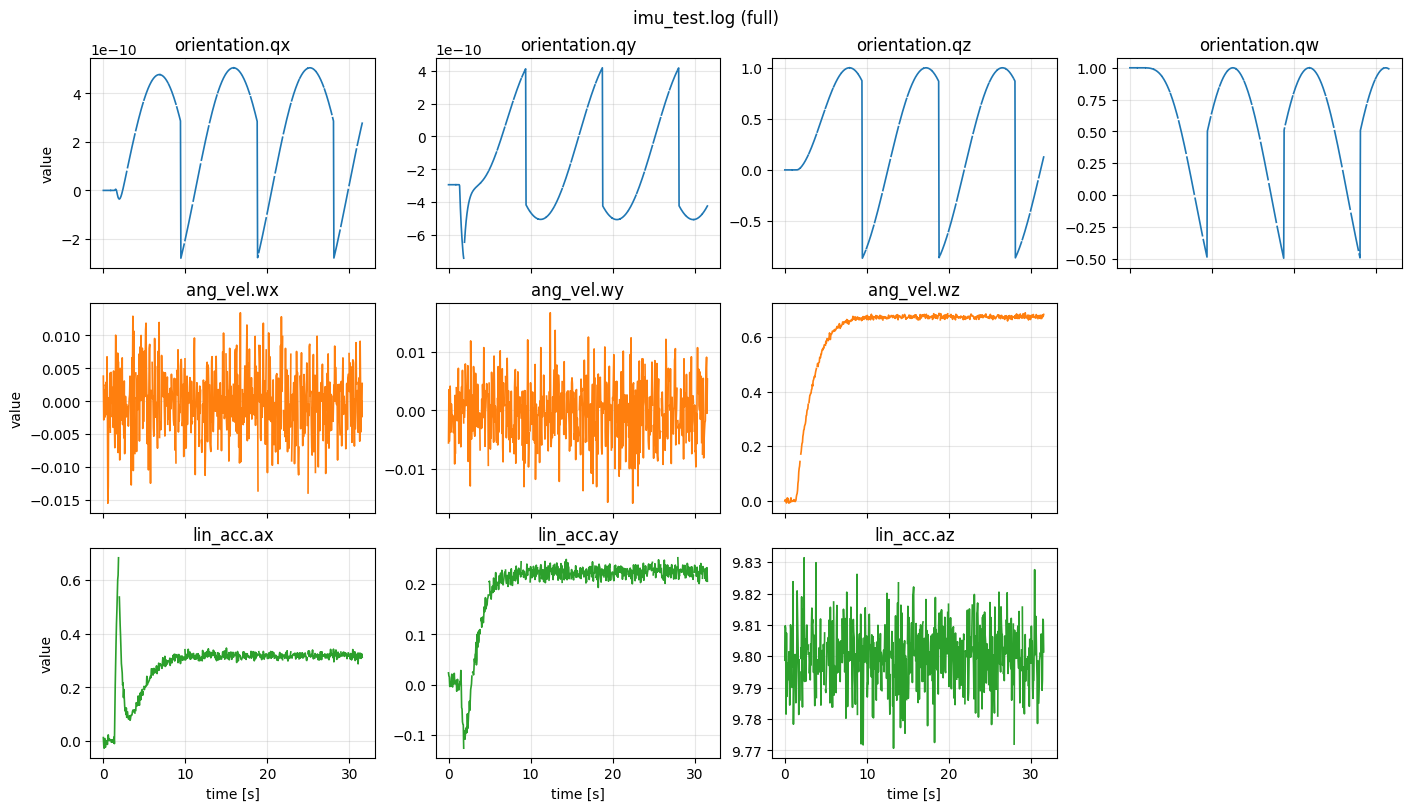

In [3]:

# Plot all samples (no trimming)
log_path = "/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/imu_test.log"
parse_and_plot(
    path=log_path,
    entity_filter="vehicle_blue::imu_link::imu_sensor",
    default_rate_hz=20.0,
    use_header_time=True,
    seconds=None,
)